<h1 style="text-align: center;">Assessment 1 - Image Segmentation Implementation</h1>
<h2 style="text-align: center;">Computer Vision and Image Analysis</h2> 
<h3 style="text-align: center;">By Ruhan Shafi | u3284342</h3>

---

## Table of Content

* Preliminaries 
    * [Importing Librarires](#importing-libraries-and-geneating-random-seed)
    * [Importing Images & Annotations](#importing-images--annotations)
    * [Verifying that Image and Annonations were imported in correctly](#verifying-that-image-and-annonations-were-imported-in-correctly)
* [Task 1 – Edge-Based Segmentation ](#task-1---edge-based-segmentation)
* [Task 2 – Region-Based Segmentation](#task-2---region-based-segmentation)
* [Task 3 – Clustering-Based Segmentation](#task-3---clustering-based-segmentation)

### Importing Libraries and Geneating Random Seed

In [1]:
import os
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print(f"OpenCV version: {cv2.__version__}")

OpenCV version: 4.13.0


### Importing Images & Annotations

This cell of code is responsible for loading in 

In [2]:
DATASET_DIR   = "oxford-iiit-pet-subset"
IMAGE_DIR     = os.path.join(DATASET_DIR, "image")
ANNOTATION_DIR= os.path.join(DATASET_DIR, "annotation")

def load_dataset():
    """
    Load all image–mask pairs from disk.
    Annotation values: 1 = foreground, 2 = background, 3 = not classified.
    Returns lists of RGB images, binary masks, and filenames.
    """
    images, masks, filenames = [], [], []
    for img_name in sorted(os.listdir(IMAGE_DIR)):
        name, _ = os.path.splitext(img_name)
        img_path  = os.path.join(IMAGE_DIR, img_name)
        mask_path = os.path.join(ANNOTATION_DIR, name + ".png")
        if not os.path.exists(mask_path):
            continue
        img  = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask = (cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) == 1).astype(np.uint8)
        images.append(img)
        masks.append(mask)
        filenames.append(name)
    return images, masks, filenames

In [3]:
def compute_metrics(pred, gt):
    """
    Pixel-wise TP/FP/FN and per-image IoU/Dice.
    Returns (iou, dice, tp, fp, fn).
    """
    tp = int(np.logical_and(pred == 1, gt == 1).sum())
    fp = int(np.logical_and(pred == 1, gt == 0).sum())
    fn = int(np.logical_and(pred == 0, gt == 1).sum())
    iou  = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0
    dice = (2 * tp) / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0
    return iou, dice, tp, fp, fn



In [4]:
def evaluate_global(segment_fn, images, masks, **kwargs):
    """
    Global IoU/Dice: accumulate TP/FP/FN across all images, then compute once.
    Also records per-image IoU for representative example selection.

    Returns dict: global_iou, global_dice, mean_ms, per_image list.
    """
    tp_total = fp_total = fn_total = 0
    per_image = []
    times = []

    for img, gt in zip(images, masks):
        t0   = time.perf_counter()
        pred = segment_fn(img, **kwargs)
        times.append((time.perf_counter() - t0) * 1000)

        # Resize prediction to match GT if needed
        if pred.shape != gt.shape:
            pred = cv2.resize(pred, (gt.shape[1], gt.shape[0]),
                              interpolation=cv2.INTER_NEAREST)

        iou, dice, tp, fp, fn = compute_metrics(pred, gt)
        tp_total += tp
        fp_total += fp
        fn_total += fn
        per_image.append(dict(iou=iou, pred=pred, gt=gt, img=img))

    global_iou  = tp_total / (tp_total + fp_total + fn_total) \
                  if (tp_total + fp_total + fn_total) > 0 else 0.0
    global_dice = (2 * tp_total) / (2 * tp_total + fp_total + fn_total) \
                  if (2 * tp_total + fp_total + fn_total) > 0 else 0.0

    return dict(
        global_iou  = global_iou,
        global_dice = global_dice,
        mean_ms     = float(np.mean(times)),
        per_image   = per_image,
    )



In [5]:


def show_examples(per_image, n=3, title=""):
    """
    Display n representative examples spread across the IoU range (best/mid/worst).
    4-panel layout: Original | Ground truth | Prediction | Error overlay.
    TP=green, FP=red, FN=blue.
    """
    sorted_imgs = sorted(per_image, key=lambda x: x['iou'])
    indices     = np.linspace(0, len(sorted_imgs) - 1, n, dtype=int)

    for idx in indices:
        entry = sorted_imgs[idx]
        img, gt, pred = entry['img'], entry['gt'], entry['pred']
        iou_val = entry['iou']

        overlay = img.copy()
        tp_m = (pred == 1) & (gt == 1)
        fp_m = (pred == 1) & (gt == 0)
        fn_m = (pred == 0) & (gt == 1)
        overlay[tp_m] = (overlay[tp_m] * 0.5 + np.array([0,   200, 0  ]) * 0.5).astype(np.uint8)
        overlay[fp_m] = (overlay[fp_m] * 0.5 + np.array([200, 0,   0  ]) * 0.5).astype(np.uint8)
        overlay[fn_m] = (overlay[fn_m] * 0.5 + np.array([0,   0,   200]) * 0.5).astype(np.uint8)

        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        fig.suptitle(f"{title}  |  IoU = {iou_val:.3f}", fontsize=11)
        axes[0].imshow(img);                 axes[0].set_title("Original")
        axes[1].imshow(gt,   cmap='gray');   axes[1].set_title("Ground truth")
        axes[2].imshow(pred, cmap='gray');   axes[2].set_title("Prediction")
        axes[3].imshow(overlay);             axes[3].set_title("Error overlay")
        legend = [
            mpatches.Patch(color=(0, 200/255, 0),  label="TP"),
            mpatches.Patch(color=(200/255, 0, 0),  label="FP"),
            mpatches.Patch(color=(0, 0, 200/255),  label="FN"),
        ]
        axes[3].legend(handles=legend, loc='lower right', fontsize=8)
        for ax in axes: ax.axis('off')
        plt.tight_layout()
        plt.show()


def print_metrics(results, label=""):
    tag = f" [{label}]" if label else ""
    print(f"=== {tag} ===")
    print(f"  Global IoU  : {results['global_iou']:.4f}")
    print(f"  Global Dice : {results['global_dice']:.4f}")
    print(f"  Speed       : {results['mean_ms']:.1f} ms / image")



In [6]:


# ── Load & split ─────────────────────────────────────────────────────────────────
images, masks, filenames = load_dataset()
print(f"Loaded {len(images)} image-mask pairs")

train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    images, masks, test_size=0.2, random_state=RANDOM_SEED
)
print(f"Train: {len(train_imgs)}  |  Val: {len(val_imgs)}")


Loaded 95 image-mask pairs
Train: 76  |  Val: 19


# Task 1 - Edge-Based Segmentation


--- Task 1: Tuning on val set ---
Best params: {'low': 30, 'high': 100, 'close_k': 21}  (val IoU = 0.3752)
===  [Task 1 — Canny] ===
  Global IoU  : 0.3707
  Global Dice : 0.5409
  Speed       : 4.0 ms / image


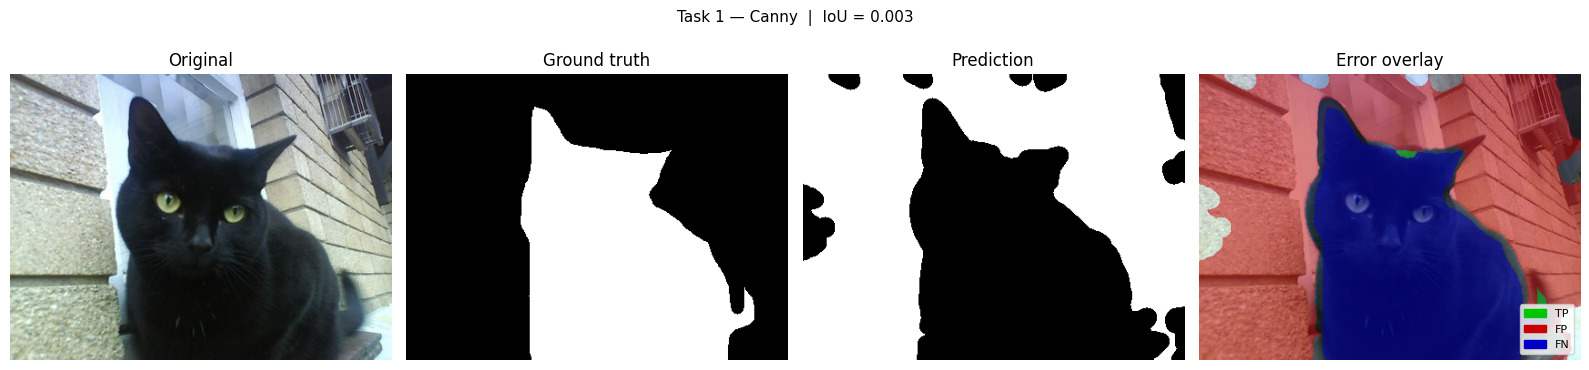

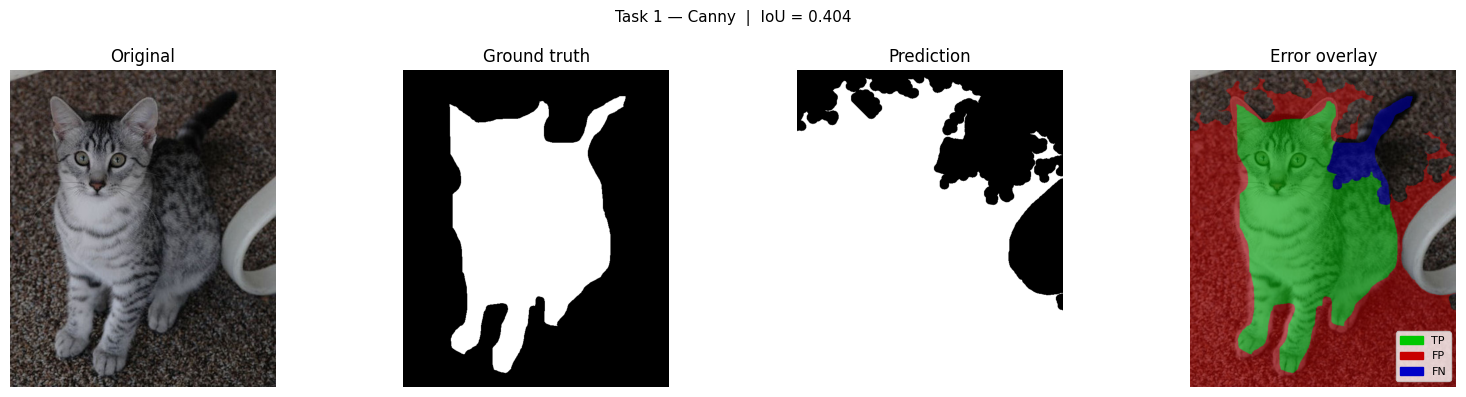

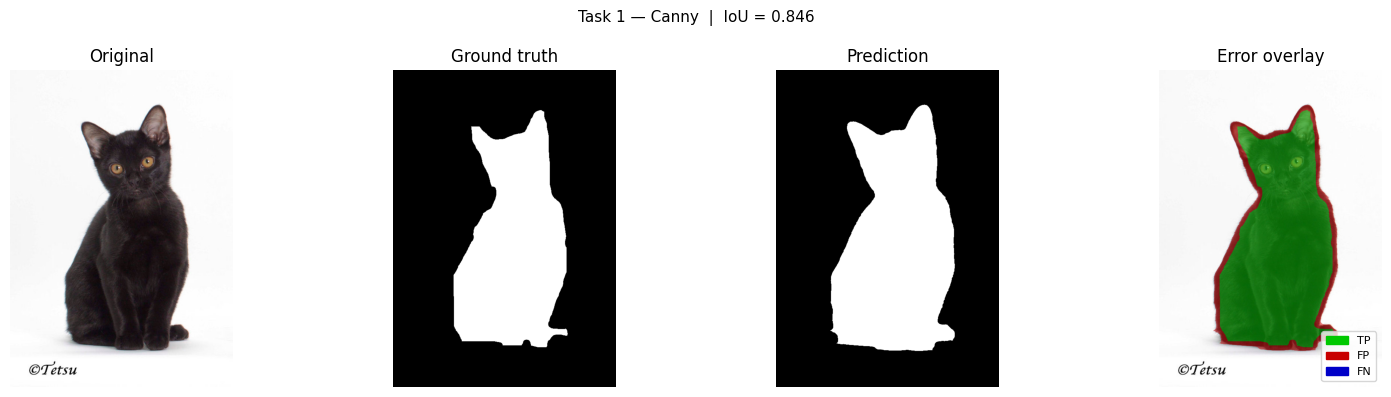

In [7]:
def canny_segment(img, low=50, high=150, blur_k=5, close_k=15):
    """
    Edge-based segmentation: Canny edge detection → morphological closing → largest contour fill.

    Args:
        img     : RGB image (H, W, 3) uint8
        low     : Canny lower hysteresis threshold
        high    : Canny upper hysteresis threshold
        blur_k  : Gaussian blur kernel size (must be odd)
        close_k : morphological closing kernel size — bridges edge gaps

    Returns:
        Binary mask (H, W) uint8: 1 = foreground, 0 = background
    """
    gray    = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, (blur_k, blur_k), 0)
    edges   = cv2.Canny(blurred, low, high)

    # Morphological closing — bridges gaps between nearby edge segments
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close_k, close_k))
    closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

    # FIX: fill only the LARGEST contour (the pet body), not all contours.
    # Filling all contours treats background clutter as foreground.
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask = np.zeros_like(gray, dtype=np.uint8)
    if contours:
        largest = max(contours, key=cv2.contourArea)
        cv2.drawContours(mask, [largest], -1, 1, thickness=cv2.FILLED)

    return mask


# ── Task 1: Parameter tuning on validation set ───────────────────────────────────
print("\n--- Task 1: Tuning on val set ---")
best_iou_t1, best_params_t1 = 0, {}

for low in [30, 50, 70]:
    for high in [100, 150, 200]:
        for close_k in [9, 15, 21]:
            res = evaluate_global(canny_segment, val_imgs, val_masks,
                                  low=low, high=high, close_k=close_k)
            if res['global_iou'] > best_iou_t1:
                best_iou_t1    = res['global_iou']
                best_params_t1 = dict(low=low, high=high, close_k=close_k)

print(f"Best params: {best_params_t1}  (val IoU = {best_iou_t1:.4f})")

# ── Task 1: Final global evaluation ─────────────────────────────────────────────
results_canny = evaluate_global(canny_segment, images, masks, **best_params_t1)
print_metrics(results_canny, "Task 1 — Canny")

# ── Task 1: Qualitative examples (best / median / worst) ────────────────────────
show_examples(results_canny['per_image'], n=3, title="Task 1 — Canny")

# Task 2 - Region-Based Segmentation


--- Task 2: Tuning on val set ---
  dist=0.3, dilate=2 → IoU=0.1948
  dist=0.3, dilate=3 → IoU=0.1903
  dist=0.3, dilate=5 → IoU=0.1951
  dist=0.5, dilate=2 → IoU=0.1906
  dist=0.5, dilate=3 → IoU=0.1951
  dist=0.5, dilate=5 → IoU=0.2067
  dist=0.7, dilate=2 → IoU=0.1119
  dist=0.7, dilate=3 → IoU=0.1268
  dist=0.7, dilate=5 → IoU=0.1467
Best params: {'dist_thresh': 0.5, 'dilate_iters': 5}  (val IoU = 0.2067)
===  [Task 2 — Watershed] ===
  Global IoU  : 0.2109
  Global Dice : 0.3483
  Speed       : 13.9 ms / image


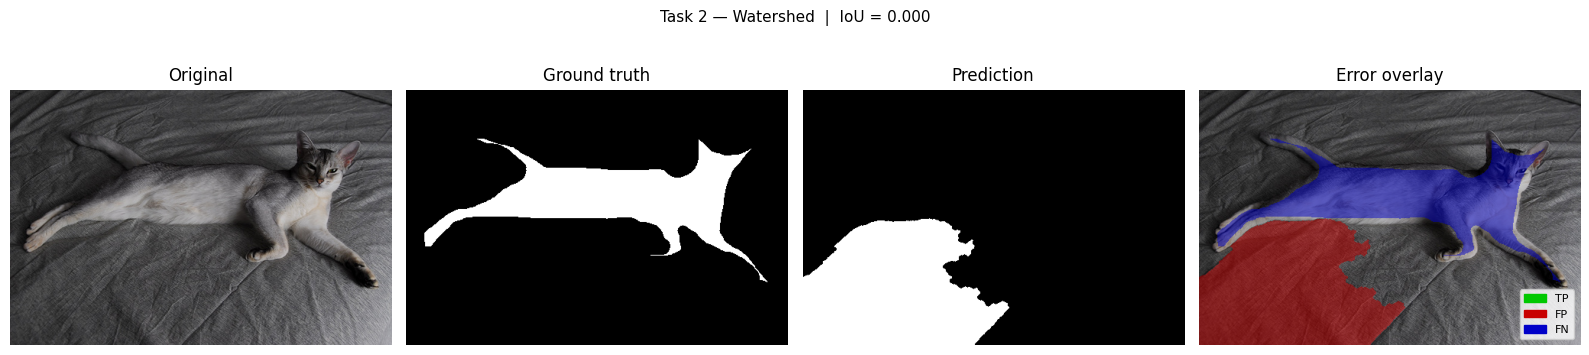

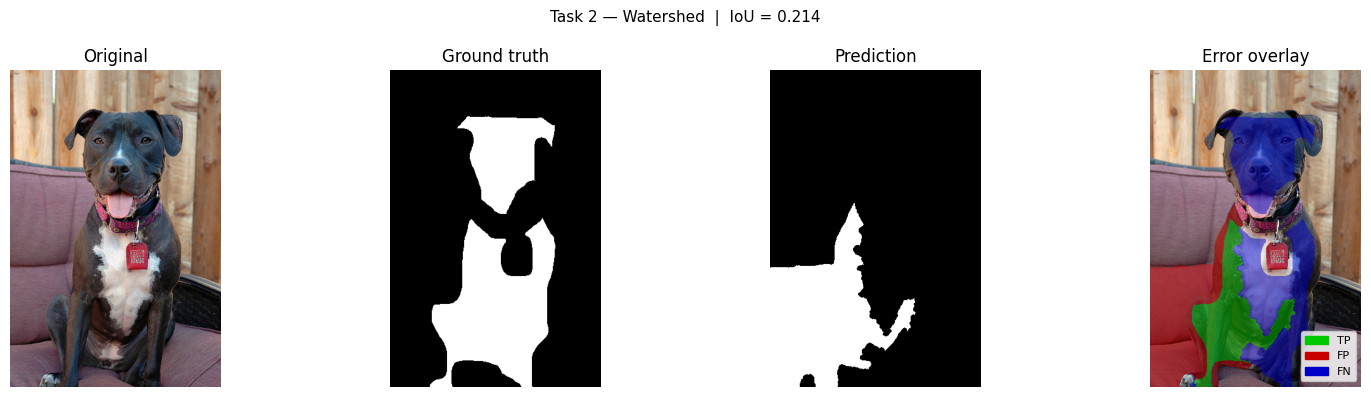

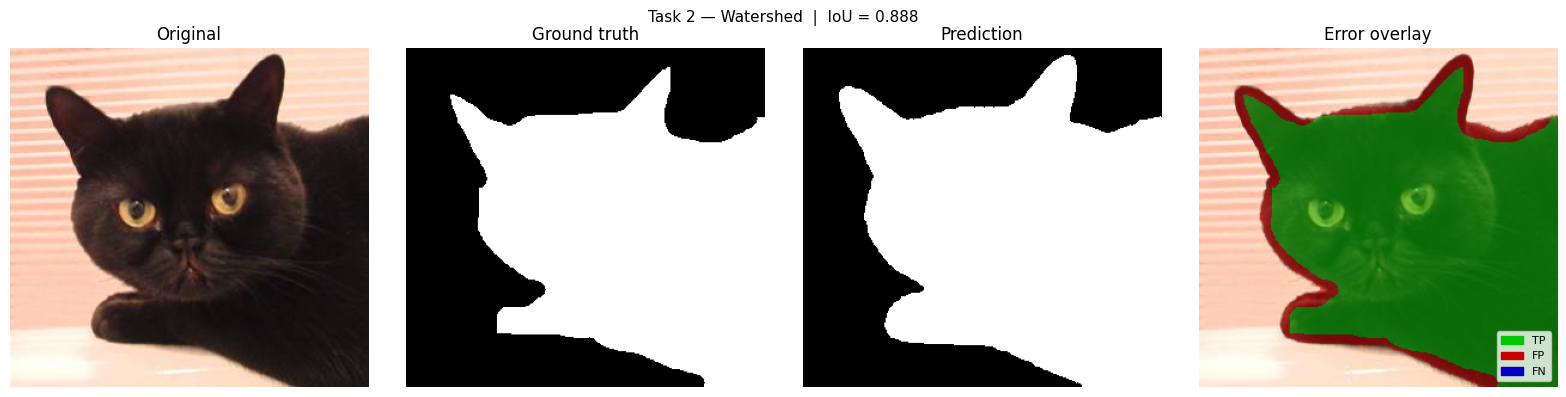

In [8]:
def _watershed_with_polarity(img_bgr, thresh_flag, dist_thresh, morph_k, dilate_iters):
    """
    Internal helper: run the full watershed pipeline with a given Otsu polarity.
    Returns the binary mask.
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Otsu threshold with chosen polarity
    _, thresh = cv2.threshold(blurred, 0, 255, thresh_flag + cv2.THRESH_OTSU)

    # Morphological opening: remove noise
    kernel  = np.ones((morph_k, morph_k), np.uint8)
    opened  = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

    # Sure background: dilated binary
    sure_bg = cv2.dilate(opened, kernel, iterations=dilate_iters)

    # Distance transform: peaks are object centres
    dist    = cv2.distanceTransform(opened, cv2.DIST_L2, 5)
    if dist.max() == 0:
        return np.zeros(gray.shape, dtype=np.uint8)

    _, sure_fg = cv2.threshold(dist, dist_thresh * dist.max(), 255, cv2.THRESH_BINARY)
    sure_fg    = sure_fg.astype(np.uint8)

    unknown = cv2.subtract(sure_bg, sure_fg)

    _, markers = cv2.connectedComponents(sure_fg)
    markers += 1                     # background → 1, objects → 2+
    markers[unknown == 255] = 0      # unknown → 0 (to be determined)

    # FIX: watershed needs a 3-channel BGR image, not RGB
    markers = cv2.watershed(img_bgr, markers)

    # FIX: identify foreground label by centre dominance, not by label > 1.
    # label == 1 is background; label == -1 is boundary.
    H, W = markers.shape
    cy0, cy1 = H // 4, 3 * H // 4
    cx0, cx1 = W // 4, 3 * W // 4
    centre_region = markers[cy0:cy1, cx0:cx1].ravel()
    # Exclude boundary (-1) and background (1) from centre vote
    valid_labels = centre_region[(centre_region > 1)]
    if len(valid_labels) == 0:
        # Fall back: any label > 1
        mask = np.where(markers > 1, 1, 0).astype(np.uint8)
    else:
        labels, counts = np.unique(valid_labels, return_counts=True)
        fg_label = labels[np.argmax(counts)]
        mask = np.where(markers == fg_label, 1, 0).astype(np.uint8)

    return mask


def watershed_segment(img, dist_thresh=0.5, morph_k=3, dilate_iters=3):
    """
    Region-based segmentation using Watershed.

    Args:
        img          : RGB image (H, W, 3) uint8
        dist_thresh  : fraction of distance transform peak used for sure-fg threshold
        morph_k      : morphological structuring element size
        dilate_iters : dilation iterations for sure-background region

    Returns:
        Binary mask (H, W) uint8: 1 = foreground, 0 = background
    """
    # FIX: convert to BGR — cv2.watershed requires a 3-channel BGR image
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    # FIX: Otsu polarity matters. Try BINARY and BINARY_INV; keep the one
    # that puts more foreground-like content in the centre region.
    mask_normal = _watershed_with_polarity(
        img_bgr, cv2.THRESH_BINARY, dist_thresh, morph_k, dilate_iters
    )
    mask_inv    = _watershed_with_polarity(
        img_bgr, cv2.THRESH_BINARY_INV, dist_thresh, morph_k, dilate_iters
    )

    # Choose whichever mask has more foreground in the central region
    H, W = img.shape[:2]
    cy0, cy1 = H // 4, 3 * H // 4
    cx0, cx1 = W // 4, 3 * W // 4
    centre_normal = mask_normal[cy0:cy1, cx0:cx1].sum()
    centre_inv    = mask_inv[cy0:cy1, cx0:cx1].sum()
    mask = mask_normal if centre_normal >= centre_inv else mask_inv

    # Morphological post-processing: close small holes in the foreground mask
    close_k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, close_k)

    return mask


# ── Task 2: Parameter tuning ─────────────────────────────────────────────────────
print("\n--- Task 2: Tuning on val set ---")
best_iou_t2, best_params_t2 = 0, {}

for dt in [0.3, 0.5, 0.7]:
    for di in [2, 3, 5]:
        res = evaluate_global(watershed_segment, val_imgs, val_masks,
                              dist_thresh=dt, dilate_iters=di)
        print(f"  dist={dt}, dilate={di} → IoU={res['global_iou']:.4f}")
        if res['global_iou'] > best_iou_t2:
            best_iou_t2    = res['global_iou']
            best_params_t2 = dict(dist_thresh=dt, dilate_iters=di)

print(f"Best params: {best_params_t2}  (val IoU = {best_iou_t2:.4f})")

# ── Task 2: Final evaluation ─────────────────────────────────────────────────────
results_watershed = evaluate_global(watershed_segment, images, masks, **best_params_t2)
print_metrics(results_watershed, "Task 2 — Watershed")

# ── Task 2: Qualitative examples ─────────────────────────────────────────────────
show_examples(results_watershed['per_image'], n=3, title="Task 2 — Watershed")

# Task 3 - Clustering-Based Segmentation


--- Task 3: Feature mode comparison ---
Mode            IoU     Dice   ms/img
----------------------------------------
rgb          0.3121   0.4757     18.8  (k=2)
hsv          0.3377   0.5049     19.6  (k=2)
hsv+xy       0.3983   0.5697     29.4  (k=3)


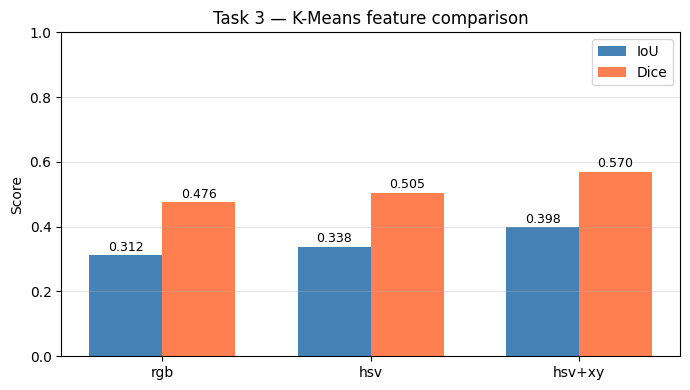


Best feature mode: hsv+xy


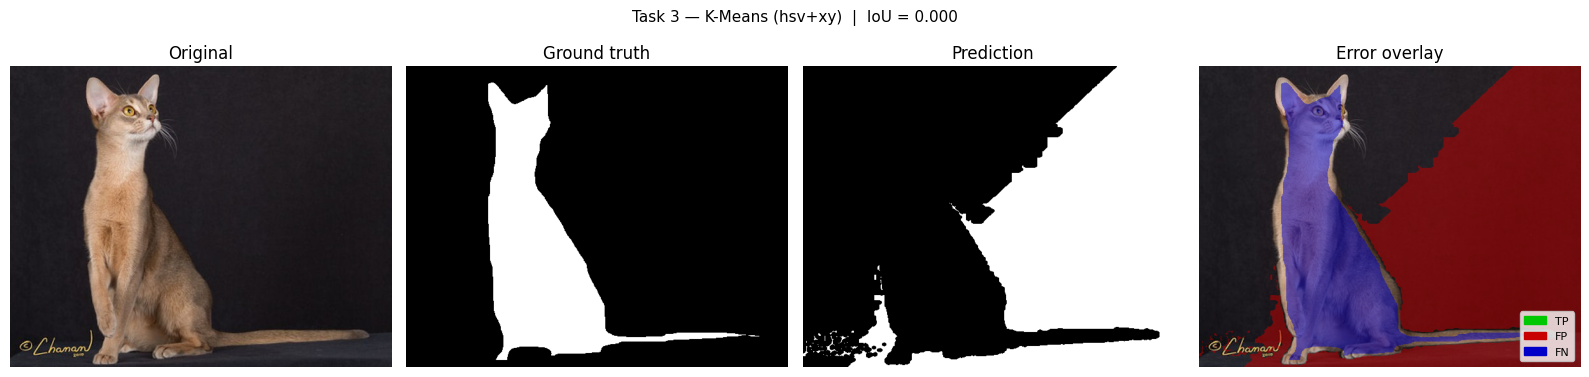

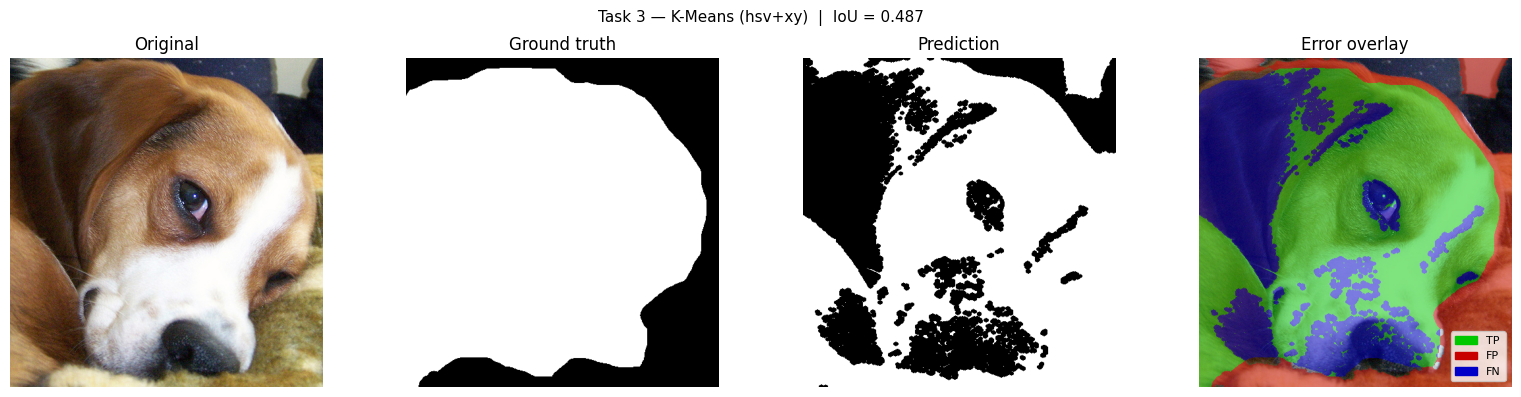

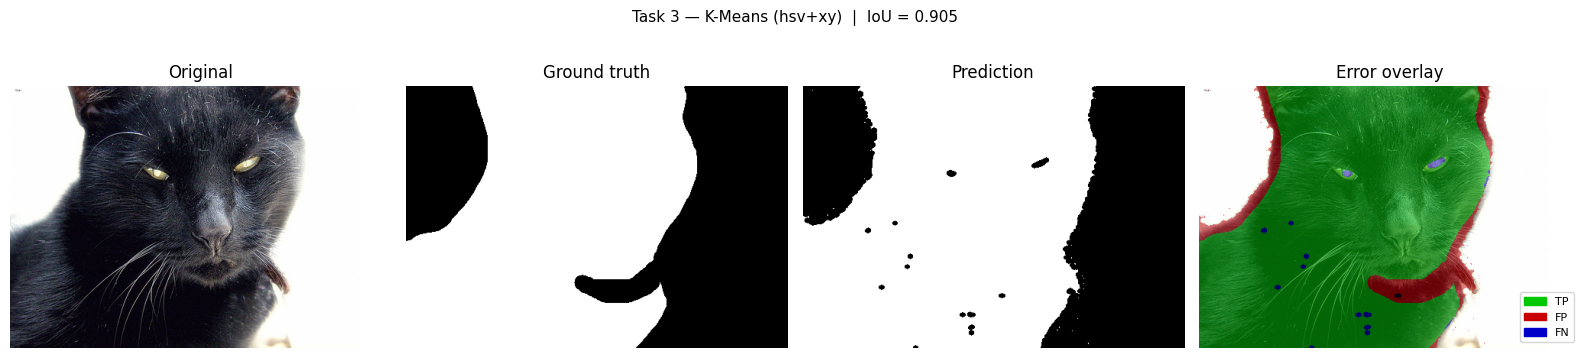

In [9]:
def build_features(img, mode='hsv+xy'):
    """
    Build a pixel-level feature matrix for K-Means.

    Modes:
        'rgb'    : normalised RGB, shape (H*W, 3)
        'hsv'    : normalised HSV, shape (H*W, 3)
        'hsv+xy' : HSV + normalised spatial coords, shape (H*W, 5)

    All channels normalised to [0, 1] so spatial features don't dominate.
    """
    H, W = img.shape[:2]

    if mode == 'rgb':
        colour = img.astype(np.float32) / 255.0
    else:
        colour = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(np.float32)
        colour /= np.array([179., 255., 255.], dtype=np.float32)

    features = colour.reshape(-1, 3)

    if '+xy' in mode:
        # Normalised pixel coordinates; scaled by 0.5 to balance with colour features
        xs = np.tile(np.linspace(0, 1, W), H).astype(np.float32) * 0.5
        ys = np.repeat(np.linspace(0, 1, H), W).astype(np.float32) * 0.5
        features = np.hstack([features, xs[:, None], ys[:, None]])

    return features


def centre_foreground_label(labels_2d, k):
    """
    Return the cluster label that most dominates the central 40% of the image.
    This is robust to cases where the pet fills more than half the frame.
    """
    H, W = labels_2d.shape
    cy0, cy1 = int(H * 0.3), int(H * 0.7)
    cx0, cx1 = int(W * 0.3), int(W * 0.7)
    centre = labels_2d[cy0:cy1, cx0:cx1].ravel()
    counts = np.bincount(centre, minlength=k)
    return int(np.argmax(counts))


def kmeans_segment(img, k=3, mode='hsv+xy', max_iter=10, attempts=3):
    """
    Clustering-based segmentation using K-Means (cv2.kmeans).

    Args:
        img      : RGB image (H, W, 3) uint8
        k        : number of clusters
        mode     : feature space — 'rgb', 'hsv', or 'hsv+xy'
        max_iter : K-Means iteration limit
        attempts : number of independent runs (best compactness kept)

    Returns:
        Binary mask (H, W) uint8: 1 = foreground, 0 = background
    """
    H, W = img.shape[:2]
    features = build_features(img, mode=mode)

    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, max_iter, 1.0)
    _, label_flat, _ = cv2.kmeans(
        features, k, None, criteria, attempts, cv2.KMEANS_PP_CENTERS
    )
    labels_2d = label_flat.reshape(H, W)

    # FIX: assign foreground by centre dominance, not by "not the largest cluster"
    fg_label = centre_foreground_label(labels_2d, k)
    mask = np.where(labels_2d == fg_label, 1, 0).astype(np.uint8)

    # Morphological closing to fill small holes within the foreground region
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask   = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    return mask


# ── Task 3: Feature space comparison (required by rubric) ────────────────────────
print("\n--- Task 3: Feature mode comparison ---")
feature_modes   = ['rgb', 'hsv', 'hsv+xy']
kmeans_results  = {}

print(f"{'Mode':<10} {'IoU':>8} {'Dice':>8} {'ms/img':>8}")
print("-" * 40)
for mode in feature_modes:
    # Also grid-search k ∈ {2, 3} on val set for each mode
    best_k, best_val_iou = 2, 0
    for k in [2, 3]:
        r = evaluate_global(kmeans_segment, val_imgs, val_masks, k=k, mode=mode)
        if r['global_iou'] > best_val_iou:
            best_val_iou = r['global_iou']
            best_k       = k

    # Final evaluation on full dataset with best k
    res = evaluate_global(kmeans_segment, images, masks, k=best_k, mode=mode)
    kmeans_results[mode] = dict(**res, best_k=best_k)
    print(f"{mode:<10} {res['global_iou']:>8.4f} {res['global_dice']:>8.4f} "
          f"{res['mean_ms']:>8.1f}  (k={best_k})")

# ── Task 3: Feature comparison bar chart ─────────────────────────────────────────
modes  = list(kmeans_results.keys())
ious   = [kmeans_results[m]['global_iou']  for m in modes]
dices  = [kmeans_results[m]['global_dice'] for m in modes]
x      = np.arange(len(modes))
width  = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
b1 = ax.bar(x - width/2, ious,  width, label='IoU',  color='steelblue')
b2 = ax.bar(x + width/2, dices, width, label='Dice', color='coral')
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(modes)
ax.set_ylim(0, 1.0); ax.set_ylabel('Score')
ax.set_title('Task 3 — K-Means feature comparison')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

# ── Task 3: Best mode qualitative examples ───────────────────────────────────────
best_mode = max(kmeans_results, key=lambda m: kmeans_results[m]['global_iou'])
print(f"\nBest feature mode: {best_mode}")
show_examples(kmeans_results[best_mode]['per_image'], n=3,
              title=f"Task 3 — K-Means ({best_mode})")

## Extension


--- EXTENSION: Morphological post-processing ---
  Canny+morph                  IoU=0.3717  Dice=0.5419
  Watershed+morph              IoU=0.2121  Dice=0.3500
  KMeans(hsv+xy)+morph         IoU=0.3887  Dice=0.5599


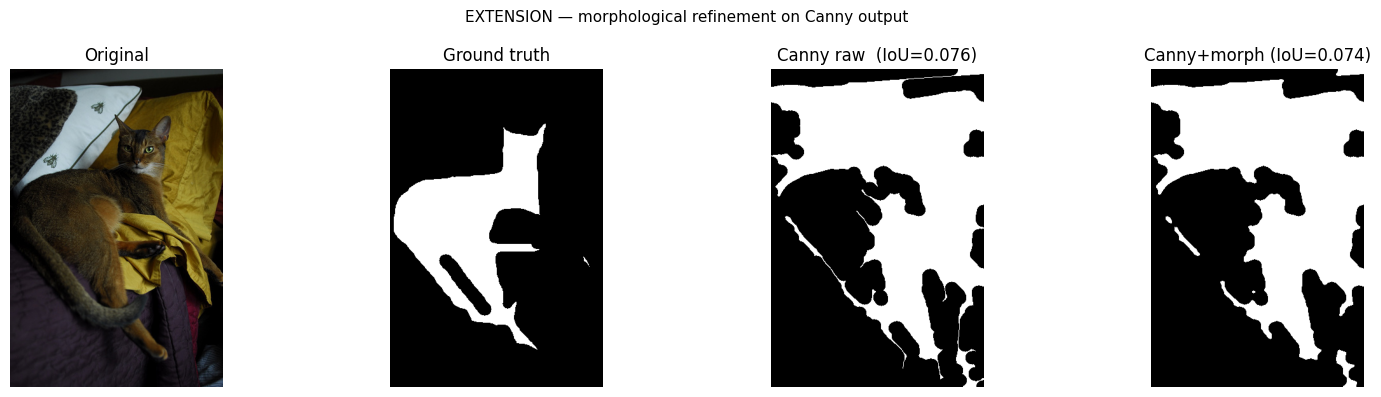

In [10]:
def morph_refine(mask, open_k=5, close_k=11):
    """
    Post-process a binary segmentation mask with morphological open then close.

    Args:
        mask    : binary mask (H, W) uint8
        open_k  : opening kernel size — removes small foreground blobs (FP noise)
        close_k : closing kernel size — fills holes in foreground (FN noise)

    Returns:
        Refined binary mask (H, W) uint8
    """
    k_open  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (open_k,  open_k))
    k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close_k, close_k))
    refined = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  k_open)
    refined = cv2.morphologyEx(refined, cv2.MORPH_CLOSE, k_close)
    return refined


def make_refined_fn(segment_fn, **seg_kwargs):
    """Wrap any segment function with morph_refine post-processing."""
    def refined(img, open_k=5, close_k=11):
        raw = segment_fn(img, **seg_kwargs)
        return morph_refine(raw, open_k=open_k, close_k=close_k)
    return refined


print("\n--- EXTENSION: Morphological post-processing ---")

ext_results = {}
for name, segment_fn, best_params in [
    ("Canny+morph",     canny_segment,     best_params_t1),
    ("Watershed+morph", watershed_segment, best_params_t2),
    (f"KMeans({best_mode})+morph", kmeans_segment,
     dict(k=kmeans_results[best_mode]['best_k'], mode=best_mode)),
]:
    # Tune open_k/close_k on val set
    best_ext_iou, best_ext_params = 0, {}
    for ok in [3, 5, 7]:
        for ck in [7, 11, 15]:
            raw_fn   = make_refined_fn(segment_fn, **best_params)
            res_val  = evaluate_global(raw_fn, val_imgs, val_masks, open_k=ok, close_k=ck)
            if res_val['global_iou'] > best_ext_iou:
                best_ext_iou    = res_val['global_iou']
                best_ext_params = dict(open_k=ok, close_k=ck)

    refined_fn = make_refined_fn(segment_fn, **best_params)
    res = evaluate_global(refined_fn, images, masks, **best_ext_params)
    ext_results[name] = res
    print(f"  {name:<28} IoU={res['global_iou']:.4f}  Dice={res['global_dice']:.4f}")

# ── Extension: before/after comparison on one example ───────────────────────────
sample_img, sample_gt = images[5], masks[5]

raw_canny  = canny_segment(sample_img, **best_params_t1)
ref_canny  = morph_refine(raw_canny)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("EXTENSION — morphological refinement on Canny output", fontsize=11)
axes[0].imshow(sample_img);             axes[0].set_title("Original")
axes[1].imshow(sample_gt,  cmap='gray');axes[1].set_title("Ground truth")
axes[2].imshow(raw_canny,  cmap='gray');axes[2].set_title(f"Canny raw  (IoU={compute_metrics(raw_canny, sample_gt)[0]:.3f})")
axes[3].imshow(ref_canny,  cmap='gray');axes[3].set_title(f"Canny+morph (IoU={compute_metrics(ref_canny, sample_gt)[0]:.3f})")
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

## Task 4


=== Task 4: Final comparison ===

Method                    Global IoU  Global Dice   ms/img
------------------------------------------------------------
Canny                         0.3707       0.5409      4.0
Watershed                     0.2109       0.3483     13.9
K-Means (hsv+xy)              0.3983       0.5697     29.4


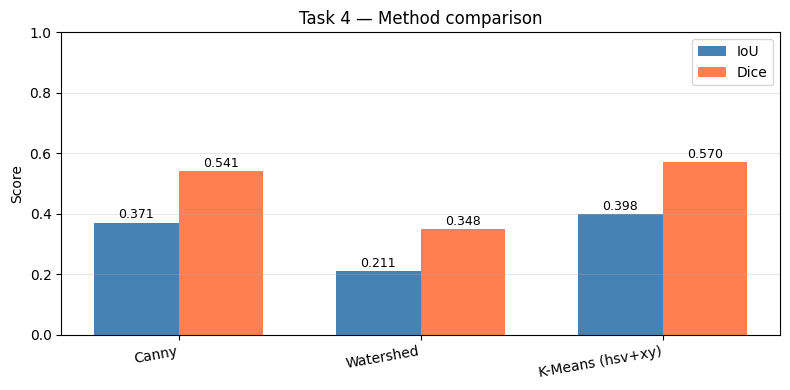

In [11]:
print("\n=== Task 4: Final comparison ===")
all_results = {
    "Canny"                  : results_canny,
    "Watershed"              : results_watershed,
    f"K-Means ({best_mode})" : kmeans_results[best_mode],
}

print(f"\n{'Method':<24} {'Global IoU':>11} {'Global Dice':>12} {'ms/img':>8}")
print("-" * 60)
for name, res in all_results.items():
    print(f"{name:<24} {res['global_iou']:>11.4f} {res['global_dice']:>12.4f} {res['mean_ms']:>8.1f}")

# ── Comparison bar chart ──────────────────────────────────────────────────────────
names  = list(all_results.keys())
ious   = [all_results[m]['global_iou']  for m in names]
dices  = [all_results[m]['global_dice'] for m in names]
x      = np.arange(len(names))
width  = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
b1 = ax.bar(x - width/2, ious,  width, label='IoU',  color='steelblue')
b2 = ax.bar(x + width/2, dices, width, label='Dice', color='coral')
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(names, rotation=10, ha='right')
ax.set_ylim(0, 1.0); ax.set_ylabel('Score')
ax.set_title('Task 4 — Method comparison')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()